<a href="https://colab.research.google.com/github/trungnam844-droid/marketing-ab-testing-analysis/blob/main/Marketing_AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def eda_overview(df):
    print(f"1.Shape: \n{df.shape}")

    print(f"\n2.Info:")
    df.info()

    print(f"\n3.Missing values: \n{df.isnull().sum()}")

    print(f"\n4.Duplicate values: \n{df.duplicated().sum()}")

In [ ]:
url = r"https://drive.google.com/file/d/11_WuCg9auCpE4bsych6a-9K2gf5tE-jk/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(download_url)
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
eda_overview(df)

1.Shape: 
(588101, 7)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB

3.Missing values: 
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

4.Duplicate values: 
0


In [ ]:
# Drop cột Unnamed: 0
df = df.drop(columns='Unnamed: 0')

In [ ]:
# rename tên các cột: user id, test group, total ads, most ads day, most ads hour
df = df.rename(columns={'user id': 'user_id',
                        'test group': 'test_group',
                        'total ads': 'total_ads',
                        'most ads day': 'most_ads_day',
                        'most ads hour': 'most_ads_hour'}
 )

In [ ]:
# check trùng user id
df['user_id'].duplicated().sum()

np.int64(0)

In [ ]:
df['test_group'].value_counts()

,count
test_group,
ad,564577
psa,23524


In [ ]:
# Tạo cột group

df['group'] = df['test_group'].map({
    'ad': 'treatment', # treatment (có ads)
    'psa': 'control'   # control (không ads)
})

In [ ]:
df['converted'].value_counts()

,count
converted,
False,573258
True,14843


In [ ]:
# change type user_id, converted
df['user_id'] = df['user_id'].astype(str)
df['converted'] = df['converted'].astype(int)

In [ ]:
# check outlier

df[['total_ads', 'most_ads_hour']].describe()

,total_ads,most_ads_hour
count,588101.000000,588101.000000
mean,24.820876,14.469061
std,43.715181,4.834634
min,1.000000,0.000000
25%,4.000000,11.000000
50%,13.000000,14.000000
75%,27.000000,18.000000
max,2065.000000,23.000000


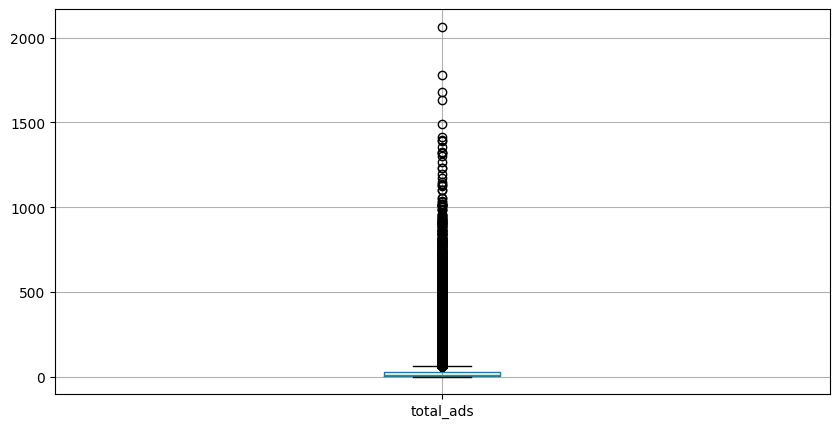

In [ ]:
plt.figure(figsize=(10, 5))
df.boxplot(column='total_ads')
plt.show()

In [ ]:
# xác định threshold
threshold = df['total_ads'].quantile(0.99)

# filter
df = df[df['total_ads'] < threshold]

In [ ]:
df['total_ads'].sort_values(ascending=False).head(10)

,total_ads
59705,201
29997,201
40090,201
30250,201
10559,201
19373,201
94322,201
53418,201
33794,201
11562,201


In [ ]:
df['total_ads'].describe()

,total_ads
count,582216.000000
mean,21.787785
std,28.035705
min,1.000000
25%,4.000000
50%,13.000000
75%,27.000000
max,201.000000


In [ ]:
df['ads_bucket'] = pd.cut(
    df['total_ads'],
    bins=[0, 5, 15, 30, 60, 201],
    labels=['very_low', 'low', 'medium', 'high', 'very_high']
)

| **Bucket**    | Range  | Lý do              |
| --------- | ------ | ------------------ |
| very_low  | 0–5    | gần 25% đầu        |
| low       | 5–15   | quanh median       |
| medium    | 15–30  | vùng phổ biến      |
| high      | 30–60  | bắt đầu cao        |
| very_high | 60–201 | tail (heavy users) |


In [ ]:
df.groupby('ads_bucket', observed=False)['converted'].agg(['mean', 'count'])

,mean,count
ads_bucket,,
very_low,0.002525,177823
low,0.006052,151679
medium,0.013951,127879
high,0.049434,77335
very_high,0.146316,47500


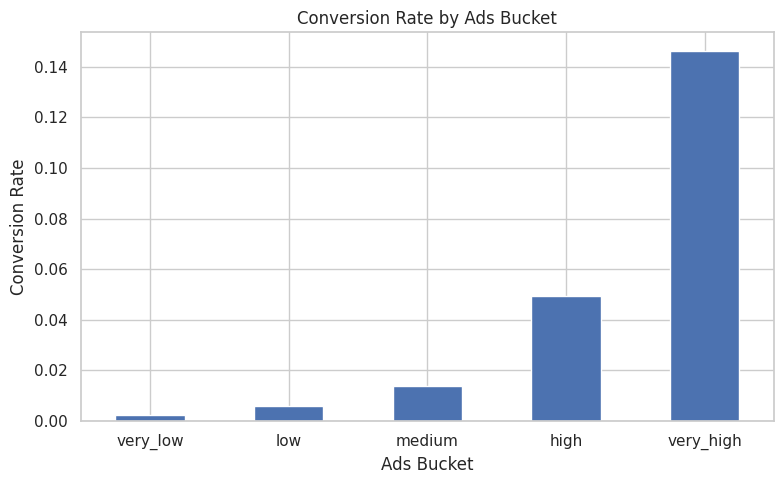

In [ ]:
import os

# Tạo summary
bucket_summary = df.groupby('ads_bucket', observed=False)['converted'].agg(['mean','count'])

plt.figure(figsize=(8,5))

bucket_summary['mean'].plot(kind='bar')

plt.title('Conversion Rate by Ads Bucket')
plt.xlabel('Ads Bucket')
plt.ylabel('Conversion Rate')

plt.xticks(rotation=0)

plt.tight_layout()

# Tạo thư mục 'images'
os.makedirs('images', exist_ok=True)

# Lưu ảnh
plt.savefig('images/conversion_by_bucket.png')

plt.show()

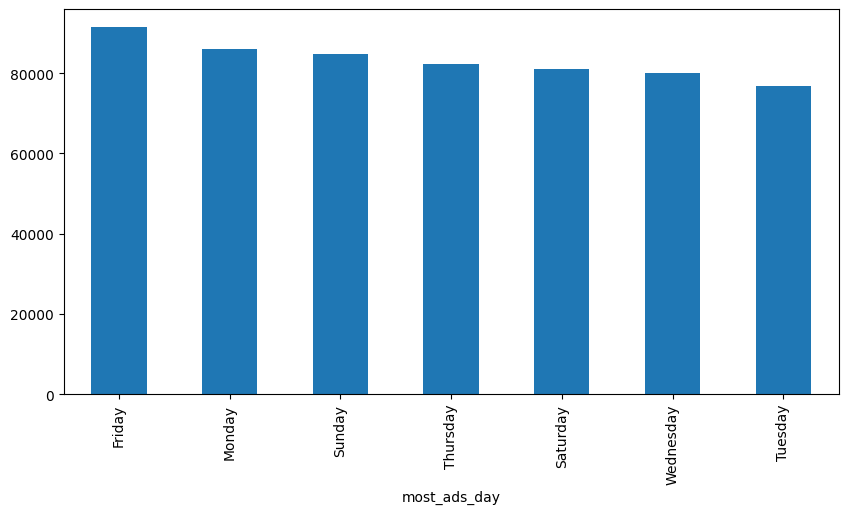

In [ ]:
# visualize most_ads_day
plt.figure(figsize=(10, 5))
df['most_ads_day'].value_counts().plot(kind='bar')
plt.show()

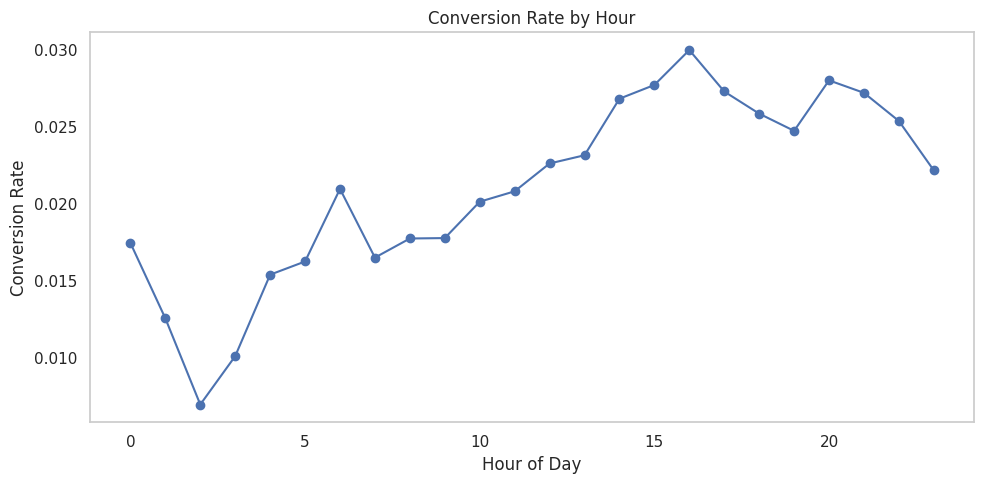

In [ ]:
# visual most_ads_hour

plt.figure(figsize=(10,5))

df.groupby('most_ads_hour')['converted'].mean().plot(kind='line', marker='o')

plt.title('Conversion Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Conversion Rate')

plt.grid()

plt.tight_layout()

# Lưu ảnh
plt.savefig('images/conversion_by_hour.png')

plt.show()

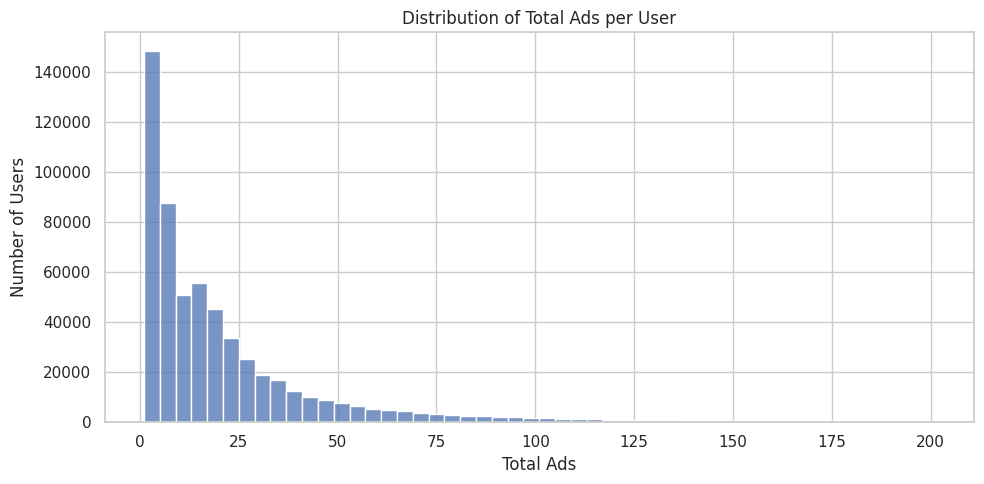

In [ ]:
sns.set(style='whitegrid')

plt.figure(figsize=(10,5))

sns.histplot(df['total_ads'], bins=50)

plt.title('Distribution of Total Ads per User')
plt.xlabel('Total Ads')
plt.ylabel('Number of Users')

plt.tight_layout()

# Lưu ảnh
plt.savefig('images/ads_distribution.png')

plt.show()

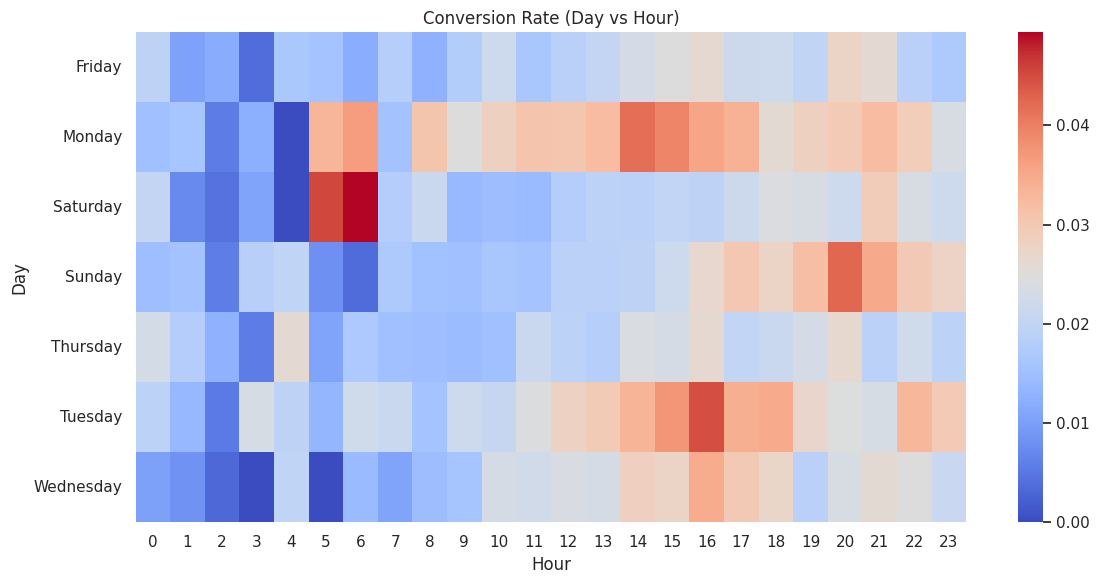

In [ ]:
# Pivot table
heatmap_data = df.pivot_table(
    values='converted',
    index='most_ads_day',
    columns='most_ads_hour',
    aggfunc='mean'
)

# visual

plt.figure(figsize=(12,6))

sns.heatmap(heatmap_data, cmap='coolwarm')

plt.title('Conversion Rate (Day vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Day')

plt.tight_layout()

# Lưu ảnh
plt.savefig('images/conversion_heatmap.png')

plt.show()

## **MỤC TIÊU A/B TEST:** Ads có tác động đến conversion không?

# **Thiết lập Hypothesis**

# H0: Ads không ảnh hưởng đến conversion

# H1: Ads có ảnh hưởng đến conversion

In [ ]:
from scipy.stats import ttest_ind

control = df[df['group']=='control']['converted']
treatment = df[df['group']=='treatment']['converted']

t_stat, p_value = ttest_ind(control, treatment, equal_var=False)

print('T-stat:', t_stat)
print('P-value:', p_value)
print('Control mean:', control.mean())
print('Treatment mean:', treatment.mean())

alpha = 0.05

if p_value < alpha:
    print('\nBác bỏ H0: Ads có ảnh hưởng đến conversion')
else:
    print('\nKhông đủ cơ sở bác bỏ H0:Ads không ảnh hưởng đến conversion ')

T-stat: -9.231107339215106
P-value: 2.8748266475187175e-20
Control mean: 0.01633003867640739
Treatment mean: 0.024231321093629795

Bác bỏ H0: Ads có ảnh hưởng đến conversion


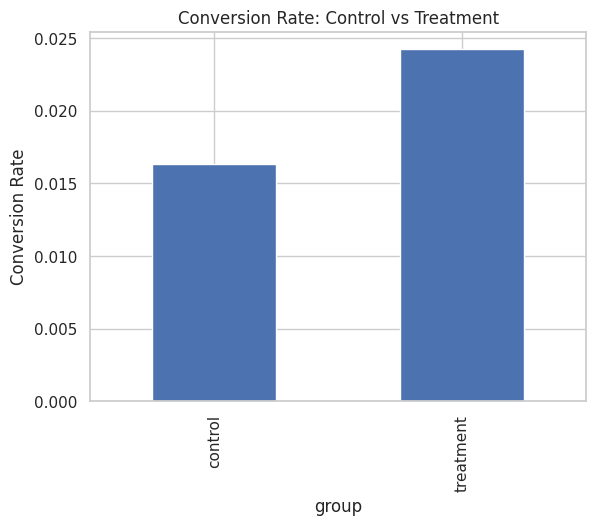

In [ ]:
group_conv = df.groupby('group')['converted'].mean()

group_conv.plot(kind='bar')

plt.title("Conversion Rate: Control vs Treatment")
plt.ylabel("Conversion Rate")

plt.savefig('images/ab_test_result.png')
plt.show()

In [ ]:
uplift = (treatment.mean() - control.mean()) / control.mean()
print(f"Conversion uplift: {uplift:.2%}")

Conversion uplift: 48.38%
